#Installing and importring libraries

In [45]:
!pip install keras joblib scipy keras-tuner

In [46]:

!pip -q install -U "plotly==5.24.1" "kaleido==0.2.1"

In [47]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from pandas import DataFrame
# Pre-procesamiento
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import seaborn as sns
# Clasificacion
from sklearn.model_selection import StratifiedKFold
from sklearn import metrics
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
# Evaluation metrics
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.model_selection import RandomizedSearchCV, RepeatedKFold
import multiprocessing
from sklearn.metrics import fbeta_score, make_scorer
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_curve, roc_auc_score
import tensorflow
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input
from tensorflow.keras import layers
from tensorflow.keras import regularizers
import keras
from keras.layers import Dense
from sklearn.utils import class_weight
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Concatenate
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.regularizers import l2
#from scikeras.wrappers import KerasClassifier
from scipy.stats import reciprocal, uniform
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
import importlib, subprocess, sys, os
import plotly.io as pio

# PATHS AND PARAMETERS

In [48]:
# ============================================================
# 0) PATHS AND PARAMETERS
# ============================================================
import os
import dill
# --- BASE MODEL artifacts ---

MODEL_BASE_FULL_PATH =  "/content/sample_data/model/good_candidate_seed114_valF10.7857_valAUC0.6364.keras"


# --- New dataset ---
NEW_DATA_PATH = "/content/sample_data/UCHW.xlsx"
NEW_SHEET = None
TARGET = "acute_GvHD_II_III_IV"


# Tuner
MAX_TRIALS_TRANSFER = 10
EPOCHS_TRANSFER = 1000
BATCH_SIZE_TRANSFER = 16

print("Base model:", MODEL_BASE_FULL_PATH)
print("New dataset:", NEW_DATA_PATH)


Base model: /content/sample_data/model/good_candidate_seed114_valF10.7857_valAUC0.6364.keras
New dataset: /content/sample_data/UCHW.xlsx


# IMPORTS AND SEEDS

In [49]:
# ============================================================
# 1) IMPORTS AND SEEDS
# ============================================================
import random
import json
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score
)

import joblib
import keras_tuner as kt

os.environ["PYTHONHASHSEED"] = "0"
random.seed(0)
np.random.seed(0)
tf.random.set_seed(0)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.19.0


# LOAD NEW DATASET AND DEFINE X_existing / X_new

In [50]:
# ============================================================
# 4) LOAD NEW DATASET AND DEFINE X_existing / X_new
# ============================================================
if NEW_SHEET is None:
    df = pd.read_excel(NEW_DATA_PATH)
else:
    df = pd.read_excel(NEW_DATA_PATH, sheet_name=NEW_SHEET)

assert TARGET in df.columns, f"Target column '{TARGET}' was not found in the new dataset"

print("New dataset shape (raw):", df.shape)
df.head()


New dataset shape (raw): (229, 15)


,recipient_gender,disease,Previous_therapy,Only_Chemotherapy,Chemotherapy_Irradiation,survival_status,Degree_of_kinship,Type_of_transplant,Graft_manipulation,extensive_chronic_GvHD,Classification: local=1; limited=2; extended=3,cGvHD_organ_ involvement: Skin=1; intestine=2; Liver=3; others=4,acute_GvHD_II_III_IV,aGvHD_organ_involvement: Skin=1; intestine=2; liver=3; other=4,stem_cell_source
0,male,Leukemia,0,0,0,0,UD,1,no manipulation,1,1,1.0,1,1.0,peripheral_blood
1,male,Leukemia,1,0,1,1,UD,1,no manipulation,0,0,0.0,1,1.0,peripheral_blood
2,female,lymphoma,1,1,0,0,itself,2,no manipulation,0,0,0.0,0,1.0,peripheral_blood
3,female,lymphoma,1,1,0,0,UD,1,no manipulation,0,0,0.0,1,1.0,peripheral_blood
4,female,Leukemia,1,0,1,1,Sibiling,1,no manipulation,1,3,1.0,1,2.0,peripheral_blood


In [51]:
df=df[df["Type_of_transplant"] == 1]
df=df.loc[:,['recipient_gender','disease','stem_cell_source','Previous_therapy','Graft_manipulation','Only_Chemotherapy','Degree_of_kinship','Chemotherapy_Irradiation','acute_GvHD_II_III_IV']]

In [52]:
df=df.dropna()
df.shape

(126, 9)

#Preproces the Dataset and spliting

In [53]:
# === df already loaded with ALL columns ===


VAL_SIZE  = 0.15
TEST_SIZE = 0.15
SEED = 16


y = df[TARGET].astype(int)
X_all = df.drop(columns=[TARGET]).copy()

# 1) split train vs temp (val+test)
train_idx, temp_idx = train_test_split(
    np.arange(len(X_all)),
    test_size=VAL_SIZE + TEST_SIZE,
    stratify=y,
    random_state=SEED
)

# 2) split temp -> val and test in the requested proportion
temp_y = y.iloc[temp_idx]
val_ratio_within_temp = VAL_SIZE / (VAL_SIZE + TEST_SIZE)
val_rel_idx, test_rel_idx = train_test_split(
    np.arange(len(temp_idx)),
    test_size=(1 - val_ratio_within_temp),
    stratify=temp_y,
    random_state=SEED
)

val_idx  = np.asarray(temp_idx)[val_rel_idx]
test_idx = np.asarray(temp_idx)[test_rel_idx]


X_train_all, X_val_all, X_test_all = X_all.iloc[train_idx], X_all.iloc[val_idx], X_all.iloc[test_idx]
y_train,     y_val,     y_test     = y.iloc[train_idx],   y.iloc[val_idx],   y.iloc[test_idx]

print("Sizes ->",
      "train:", len(X_train_all),
      "val:",   len(X_val_all),
      "test:",  len(X_test_all))



Sizes -> train: 88 val: 19 test: 19


In [54]:
# --- Define base_feature_names / raw_columns  ---
import json, numpy as np, pandas as pd, os, joblib

# Base artifacts
# Load base preprocessor
pre_base = joblib.load('/content/sample_data/preprocessor.joblib')

def get_raw_columns_from_pre(pre):
    raw_cols = []
    for name, trans, cols in pre.transformers_:
        if name == "remainder":
            continue
        if isinstance(cols, (list, tuple, np.ndarray, pd.Index)):
            raw_cols.extend(list(cols))
        elif isinstance(cols, slice):
            raise ValueError("The preprocessor uses slices; I cannot reconstruct feature names.")
        else:
            raise ValueError(f"Unsupported column selector: {type(cols)}")
    # unique and in order
    seen, ordered = set(), []
    for c in raw_cols:
        if c not in seen:
            ordered.append(c); seen.add(c)
    return ordered

# 1) Try to read meta
raw_columns = None
ohe_feature_names = None
if os.path.exists('/content/sample_data/meta.json'):
    try:
        with open('/content/sample_data/meta.json', "r") as f:
            meta = json.load(f)
        raw_columns = meta.get("raw_columns")
        ohe_feature_names = meta.get("ohe_feature_names")
    except Exception:
        pass

# 2) Complete/Rebuild if something is missing
if raw_columns is None:
    raw_columns = get_raw_columns_from_pre(pre_base)
if ohe_feature_names is None:
    try:
        ohe_feature_names = list(map(str, pre_base.get_feature_names_out()))
    except Exception:
        ohe_feature_names = [f"f{i}" for i in range(len(raw_columns))]

# 3) If what you had before were OHE names, detect and fix it
#    (base_feature_names may not exist yet; we treat it as an empty list)
try:
    base_feature_names
except NameError:
    base_feature_names = []

df_cols = set(X_all.columns)  # X_all = df without TARGET
# If base_feature_names are not in the raw df columns, we assume they were OHE
if base_feature_names and not any(col in df_cols for col in base_feature_names):
    print("⚠️ Detected: base_feature_names looked like OHE. I will use raw columns from the preprocessor.")
    base_feature_names = raw_columns
elif not base_feature_names:
    # If nothing was defined, use raw columns by default
    base_feature_names = raw_columns

# 4) Verification
missing = [c for c in base_feature_names if c not in df_cols]
if missing:
    raise KeyError(f"These raw base columns do not exist in the new dataset: {missing}")

# 5) Persist consolidated metadata (to avoid repeating this logic)
with open('/content/sample_data/preprocessor_meta.json', "w") as f:
    json.dump({"raw_columns": raw_columns,
               "ohe_feature_names": ohe_feature_names}, f, indent=2)

print("✅ Consolidated metadata. Base raw columns:", len(base_feature_names))

✅ Consolidated metadata. Base raw columns: 3


##Final sets


In [55]:
# ==================== Split inputs: EXISTING vs NEW ====================
# Use the base RAW columns (not the OHE ones)
# raw_columns comes from  from pre_base
OUT_DIR = "outputs_transfer_tuned_copy2"
os.makedirs(OUT_DIR, exist_ok=True)
X_train_exist_raw = X_train_all[raw_columns].copy()
X_val_exist_raw   = X_val_all[raw_columns].copy()
X_test_exist_raw  = X_test_all[raw_columns].copy()

X_new_cols = [c for c in X_all.columns if c not in raw_columns]
X_train_new_raw = X_train_all[X_new_cols].copy()
X_val_new_raw   = X_val_all[X_new_cols].copy()
X_test_new_raw  = X_test_all[X_new_cols].copy()

# ==================== TRANSFORMATIONS ====================
# EXISTING -> SAME preprocessor as the BASE (NO refit)
X_train_existing = pre_base.transform(X_train_exist_raw)
X_val_existing   = pre_base.transform(X_val_exist_raw)
X_test_existing  = pre_base.transform(X_test_exist_raw)

# NEW -> its own preprocessor (fit ONLY on train)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

if len(X_new_cols) > 0:
    num_cols_new = X_train_new_raw.select_dtypes(include=["number","float","int"]).columns.tolist()
    cat_cols_new = [c for c in X_train_new_raw.columns if c not in num_cols_new]

    pre_new = ColumnTransformer(
        transformers=[
            ("cat", Pipeline([
                ("imp", SimpleImputer(strategy="most_frequent")),
                ("oh",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
            ]), cat_cols_new),
            ("num", Pipeline([
                ("imp", SimpleImputer(strategy="median")),
                ("sc",  StandardScaler())
            ]), num_cols_new),
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )

    X_train_new = pre_new.fit_transform(X_train_new_raw)
    X_val_new   = pre_new.transform(X_val_new_raw)
    X_test_new  = pre_new.transform(X_test_new_raw)

    os.makedirs(OUT_DIR, exist_ok=True)
    joblib.dump(pre_new, os.path.join(OUT_DIR, "preprocessor_new.joblib"))
else:
    # No new columns: create empty matrices (useful to keep the API)
    X_train_new = np.zeros((len(X_train_all), 0), dtype=float)
    X_val_new   = np.zeros((len(X_val_all),   0), dtype=float)
    X_test_new  = np.zeros((len(X_test_all),  0), dtype=float)
    pre_new = None

print("Shapes EXISTING ->",
      "train:", X_train_existing.shape,
      "val:",   X_val_existing.shape,
      "test:",  X_test_existing.shape)
print("Shapes NEW ->",
      "train:", X_train_new.shape,
      "val:",   X_val_new.shape,
      "test:",  X_test_new.shape)

# (Optional) save matrices to quickly rerun
np.savez_compressed(
    os.path.join(OUT_DIR , "matrices_train_val_test.npz"),
    X_train_existing=X_train_existing, X_val_existing=X_val_existing, X_test_existing=X_test_existing,
    X_train_new=X_train_new, X_val_new=X_val_new, X_test_new=X_test_new,
    y_train=y_train.values, y_val=y_val.values, y_test=y_test.values
)

Shapes EXISTING -> train: (88, 8) val: (19, 8) test: (19, 8)
Shapes NEW -> train: (88, 12) val: (19, 12) test: (19, 12)


# Evaluacion en test

In [56]:
# ============================================================
# Evaluate the top N models on TEST using thresholds from the CSV
# - CSV: runs_val_metrics_sorted.csv (cols: seed, val_best_thr)
# - Filenames: good_candidate_seed{SEED}_valF1{...}_valAUC{...}.keras
# ============================================================
import os, re, glob
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score, precision_recall_curve,
    confusion_matrix, roc_curve, auc as sk_auc, classification_report
)

# -------------------------
# Paths and configuration
# -------------------------
MODELS_DIR    = "/content/sample_data/model"   # <--- put your model folder here
OUTPUT_DIR    = "/content/sample_data/ensemble_eval_test"           # output folder
CSV_MANIFEST = "/content/sample_data/runs_val_metrics_good.csv"
THRESHOLD_FALLBACK = 0.5
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Usa arrays alineados si ya los tienes; si no, usa los originales
Xte_exist =  X_test_existing
Xte_new   =  X_test_new
yte       =  y_test
yte = np.asarray(yte).ravel()

# -------------------------
# Helpers
# -------------------------
def pr_auc(y_true, y_prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    p, r, _ = precision_recall_curve(y_true, y_prob)
    return sk_auc(r, p)

def safe_auc(y_true, y_prob):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return roc_auc_score(y_true, y_prob)
    except Exception:
        return np.nan

def plot_and_save_roc(y_true, y_prob, title, path_png):
    if len(np.unique(y_true)) < 2:
        plt.figure(figsize=(6,5))
        plt.text(0.5, 0.5, "ROC unavailble (a single class on y_test)",
                 ha="center", va="center")
        plt.axis('off')
        plt.savefig(path_png, dpi=200, bbox_inches="tight")
        plt.close()
        return None, None, None
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = sk_auc(fpr, tpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, lw=2, label=f"AUC={auc_val:.3f}")
    plt.plot([0,1], [0,1], "--", lw=1)
    plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title(title); plt.legend(); plt.grid(alpha=0.2)
    plt.savefig(path_png, dpi=200, bbox_inches="tight")
    plt.close()
    return fpr, tpr, auc_val

def plot_and_save_confusion(y_true, y_pred, title, path_png, normalize=False):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1], normalize='true' if normalize else None)
    plt.figure(figsize=(5,4))
    im = plt.imshow(cm, interpolation='nearest', aspect='auto')
    plt.title(title); plt.colorbar(im, fraction=0.046, pad=0.04)
    ticks = np.arange(2)
    plt.xticks(ticks, ['0','1']); plt.yticks(ticks, ['0','1'])
    thresh = cm.max() / 2. if cm.size else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            txt = f"{cm[i, j]:.2f}" if normalize else f"{int(cm[i, j])}"
            plt.text(j, i, txt, ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.ylabel("True label"); plt.xlabel("Predicted label")
    plt.tight_layout(); plt.savefig(path_png, dpi=200, bbox_inches="tight")
    plt.close()

# -------------------------
# Load manifest (seed → threshold)
# -------------------------
if not os.path.exists(CSV_MANIFEST):
    raise FileNotFoundError(f"Could not find the thresholds CSV: {CSV_MANIFEST}")

manifest = pd.read_csv(CSV_MANIFEST)
if "seed" not in manifest.columns or "val_best_thr" not in manifest.columns:
    raise ValueError("El CSV debe tener columnas 'seed' y 'val_best_thr'.")

# If there are duplicate seeds, keep the one with the best val_f1 (if available)
if "val_f1" in manifest.columns:
    manifest = (manifest
                .sort_values(["seed","val_f1"], ascending=[True, False])
                .drop_duplicates(subset=["seed"], keep="first"))

thr_by_seed = dict(zip(manifest["seed"].astype(int), manifest["val_best_thr"]))

# -------------------------
# Buscar y evaluar modelos
# -------------------------
model_paths = sorted(glob.glob(os.path.join(MODELS_DIR, "*.keras")))
if not model_paths:
    raise FileNotFoundError(f"No .keras files found in {MODELS_DIR}")

rows = []
roc_curves = []

for mp in model_paths:
    fname = os.path.basename(mp)
    model_name = os.path.splitext(fname)[0]

    # Extraer seed del nombre: _seed{N}_
    m = re.search(r"_seed(\d+)_", fname)
    if not m:
        print(f"⚠️  Could not extract seed from '{fname}'. Fallback threshold {THRESHOLD_FALLBACK} will be used.")
        seed = None
        thr  = THRESHOLD_FALLBACK
    else:
        seed = int(m.group(1))
        thr  = thr_by_seed.get(seed, THRESHOLD_FALLBACK)
        if pd.isna(thr):
            thr = THRESHOLD_FALLBACK

    # Load and predict
    try:
        model = tf.keras.models.load_model(mp, compile=False)
    except Exception as e:
        print(f"⚠️  Could not load {fname}: {e}")
        continue

    y_prob = model.predict([Xte_exist, Xte_new], verbose=0).ravel()
    y_pred = (y_prob >= float(thr)).astype(int)

    # Metrics
    acc = accuracy_score(yte, y_pred)
    f1  = f1_score(yte, y_pred) if len(np.unique(yte))>1 else np.nan
    auc = safe_auc(yte, y_prob)
    pra = pr_auc(yte, y_prob)

    # Classification report
    cr_dict = classification_report(yte, y_pred, labels=[0,1], output_dict=True, zero_division=0)
    pd.DataFrame(cr_dict).transpose().to_csv(
        os.path.join(OUTPUT_DIR, f"{model_name}_classification_report.csv"), index=True
    )

    # ROC y CM
    roc_png = os.path.join(OUTPUT_DIR, f"{model_name}_ROC.png")
    fpr, tpr, auc_curve = plot_and_save_roc(yte, y_prob, f"ROC - {model_name}", roc_png)
    if fpr is not None:
        roc_curves.append((fpr, tpr, f"{model_name} (AUC={auc_curve:.3f})"))

    cm_png = os.path.join(OUTPUT_DIR, f"{model_name}_confusion_matrix.png")
    cmn_png = os.path.join(OUTPUT_DIR, f"{model_name}_confusion_matrix_norm.png")
    plot_and_save_confusion(yte, y_pred, f"Confusion Matrix - {model_name}", cm_png, normalize=False)
    plot_and_save_confusion(yte, y_pred, f"Confusion Matrix (normalized) - {model_name}", cmn_png, normalize=True)

    rows.append({
        "model": model_name,
        "seed": seed,
        "path": mp,
        "threshold_used": float(thr),
        "test_f1": f1,
        "test_auc": auc,
        "test_acc": acc,
        "test_pr_auc": pra
    })

# -------------------------
# Summaries
# -------------------------
summary = pd.DataFrame(rows).sort_values(by=["test_f1","test_auc","test_acc","test_pr_auc"], ascending=[False,False,False,False])
summary_path = os.path.join(OUTPUT_DIR, "metrics.csv")
summary.to_csv(summary_path, index=False)


print("\n✅ Saved:")
print(" -", summary_path)




✅ Saved:
 - /content/sample_data/ensemble_eval_test/metrics.csv


In [57]:
model = tf.keras.models.load_model(MODEL_BASE_FULL_PATH, compile=False)

#Shap

X_train_existing shape: (88, 8)
X_train_new shape: (88, 12)
X_train_all shape: (88, 20)
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 225ms/step
Calculando valores SHAP (puede tardar un rato)...


  0%|          | 0/19 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
5731/5731 ━━━━━━━━━━━━━━━━━━━━ 38s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
5731/5731 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
5731/5731 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
5731/5731 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
5731/5731 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
5731/5731 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
5731/5731 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
5731/5731 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
5731/5731 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
5731/5731 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
5731/5731 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
5731/5731 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step
1/1 ━━━━━━━━━━━

/tmp/ipython-input-1971384791.py:118: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



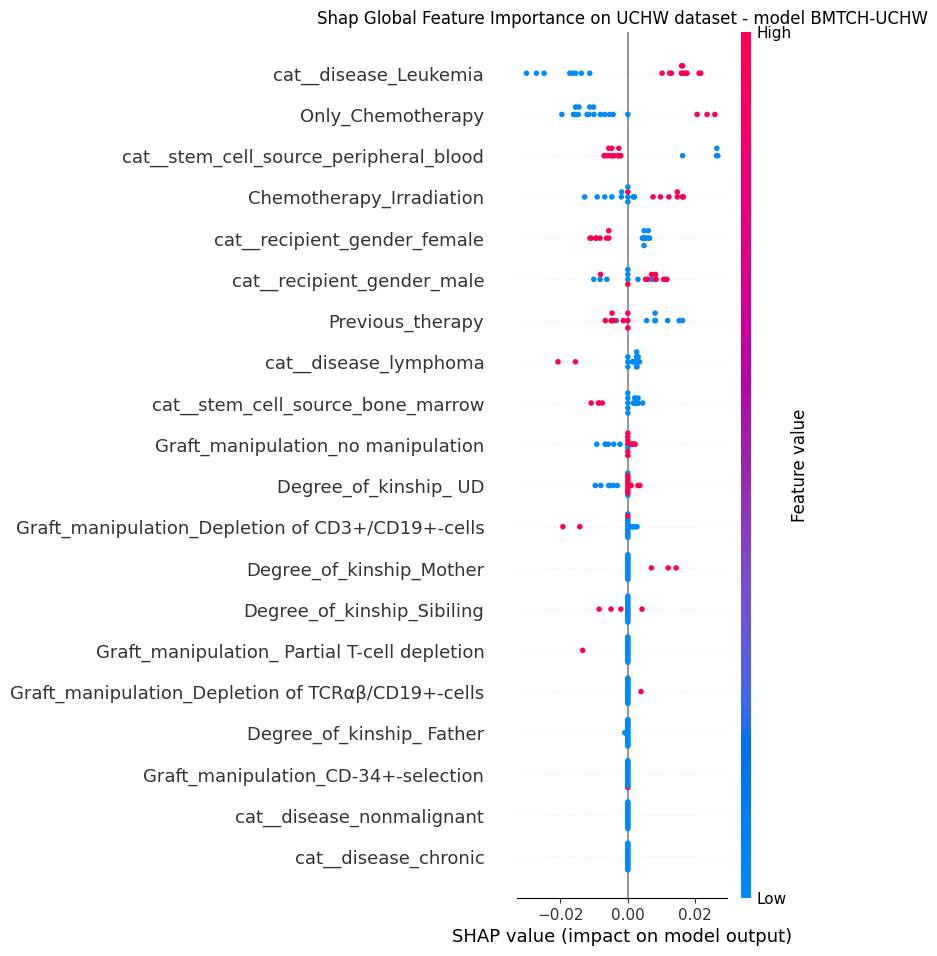

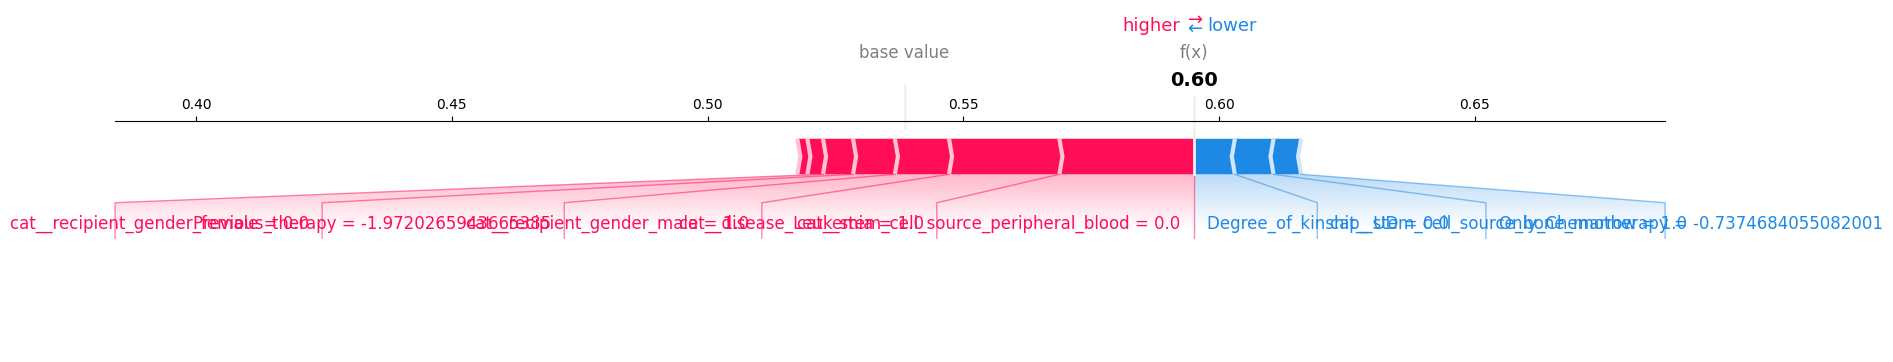

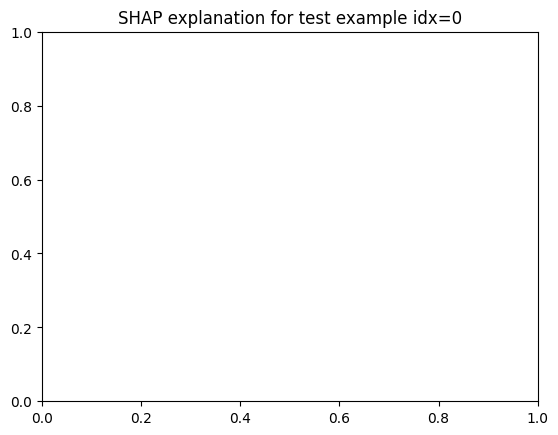

In [58]:
# ============================================================
# SHAP for model model_308 (two inputs: X_existing + X_new)
# ============================================================

!pip install shap

import shap
import numpy as np
import matplotlib.pyplot as plt
SEED=308
# ------------------------------------------------------------
# 1) Build combined matrices for SHAP
# ------------------------------------------------------------
X_train_all = np.hstack([X_train_existing, X_train_new])
X_test_all  = np.hstack([X_test_existing,  X_test_new])

n_exist = X_train_existing.shape[1]
n_new   = X_train_new.shape[1]

print("X_train_existing shape:", X_train_existing.shape)
print("X_train_new shape:",      X_train_new.shape)
print("X_train_all shape:",      X_train_all.shape)

# ------------------------------------------------------------
# 2) Prediction wrapper (splits existing / new)
# ------------------------------------------------------------
def model_308_predict(X):
    """
    X: array 2D (n_samples, n_exist + n_new)
    Devuelve probabilidades (vector 1D).
    """
    X = np.array(X)
    X_e = X[:, :n_exist]
    X_n = X[:, n_exist:]
    return model.predict([X_e, X_n]).ravel()

# ------------------------------------------------------------
# 3) Background + test sample for SHAP
# ------------------------------------------------------------
SEED = 308
background = shap.utils.sample(X_train_all, 200, random_state=SEED)
X_test_sample = shap.utils.sample(X_test_all, 100, random_state=SEED)

explainer = shap.KernelExplainer(model_308_predict, background)

print("Calculando valores SHAP (puede tardar un rato)...")
shap_values = explainer.shap_values(X_test_sample)

# Binario: shap_values suele ser [array]
if isinstance(shap_values, list) and len(shap_values) == 1:
    shap_values = shap_values[0]

print("shap_values shape:", shap_values.shape)

# ------------------------------------------------------------
# 4) Nombres de features: EXISTING (desde pre_base)
# ------------------------------------------------------------

# Intento 1: pre_base.get_feature_names_out() directamente
feature_names_exist = None
try:
    feature_names_exist = list(pre_base.get_feature_names_out())
    print("Using pre_base.get_feature_names_out() without arguments.")
except Exception as e1:
    print("Could not use pre_base.get_feature_names_out() without args:", e1)
    # Intento 2: pasar nombres originales de las columnas raw
    try:
        feature_names_exist = list(pre_base.get_feature_names_out(X_train_existing_raw.columns))
        print("Using pre_base.get_feature_names_out(X_train_existing_raw.columns).")
    except Exception as e2:
        print("get_feature_names_out with columns also failed:", e2)

# If it still has no name or the length does not match, use generic names
if feature_names_exist is None or len(feature_names_exist) != n_exist:
    print("⚠️ Could not obtain consistent names for existing; "
          "using generic names exist_i.")
    feature_names_exist = [f"exist_{i}" for i in range(n_exist)]

print("Total features existing:", len(feature_names_exist))

# ------------------------------------------------------------
# 5) Nombres de features: NEW (desde pre_new)
# ------------------------------------------------------------
feature_names_new = None
try:
    # ColumnTransformer moderno: devuelve algo tipo "cat_new__col_val", "num_new__col"
    feature_names_new = list(pre_new.get_feature_names_out())
    print("Using pre_new.get_feature_names_out().")
except Exception as e:
    print("Could not use pre_new.get_feature_names_out(), trying manual method:", e)
    try:
        ohe_new = pre_new.named_transformers_["cat_new"]
        cat_feature_names_new = list(ohe_new.get_feature_names_out(cat_cols_new))
        feature_names_new = cat_feature_names_new + list(num_cols_new)
    except Exception as e2:
        print("Also failed to obtain manual names for new:", e2)

# Fallback si algo falla
if feature_names_new is None or len(feature_names_new) != n_new:
    print("⚠️ Could not obtain consistent names for new; "
          "using generic names new_i.")
    feature_names_new = [f"new_{i}" for i in range(n_new)]

print("Total features new:", len(feature_names_new))

# ------------------------------------------------------------
# 6) Combinar nombres y verificar consistencia
# ------------------------------------------------------------
feature_names = feature_names_exist + feature_names_new

print("Total feature names:", len(feature_names))
assert len(feature_names) == X_train_all.shape[1], \
    "Feature names do not match the number of columns in X_train_all."

# ------------------------------------------------------------
# 7) Summary plot: importancia global
# ------------------------------------------------------------
shap.summary_plot(
    shap_values,
    X_test_sample,
    feature_names=feature_names,
    show=False
)
plt.title("Shap Global Feature Importance on UCHW dataset - model BMTCH-UCHW")
out_pdfshap = "Shap_Global.pdf"
plt.savefig(out_pdfshap, format="pdf", bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 8) Force plot: individual explanation
# ------------------------------------------------------------
idx = 0  # change this index to see another test example

shap.force_plot(
    explainer.expected_value,
    shap_values[idx, :],
    X_test_sample[idx, :],
    feature_names=feature_names,
    matplotlib=True
)
plt.title(f"SHAP explanation for test example idx={idx}")
plt.show()


In [59]:
import shap

# inicializa el motor JS de SHAP (necesario para force_plot interactivo)
shap.initjs()

idx = 0  # ejemplo de test a explicar

shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_test_sample[idx],
    feature_names=feature_names
)


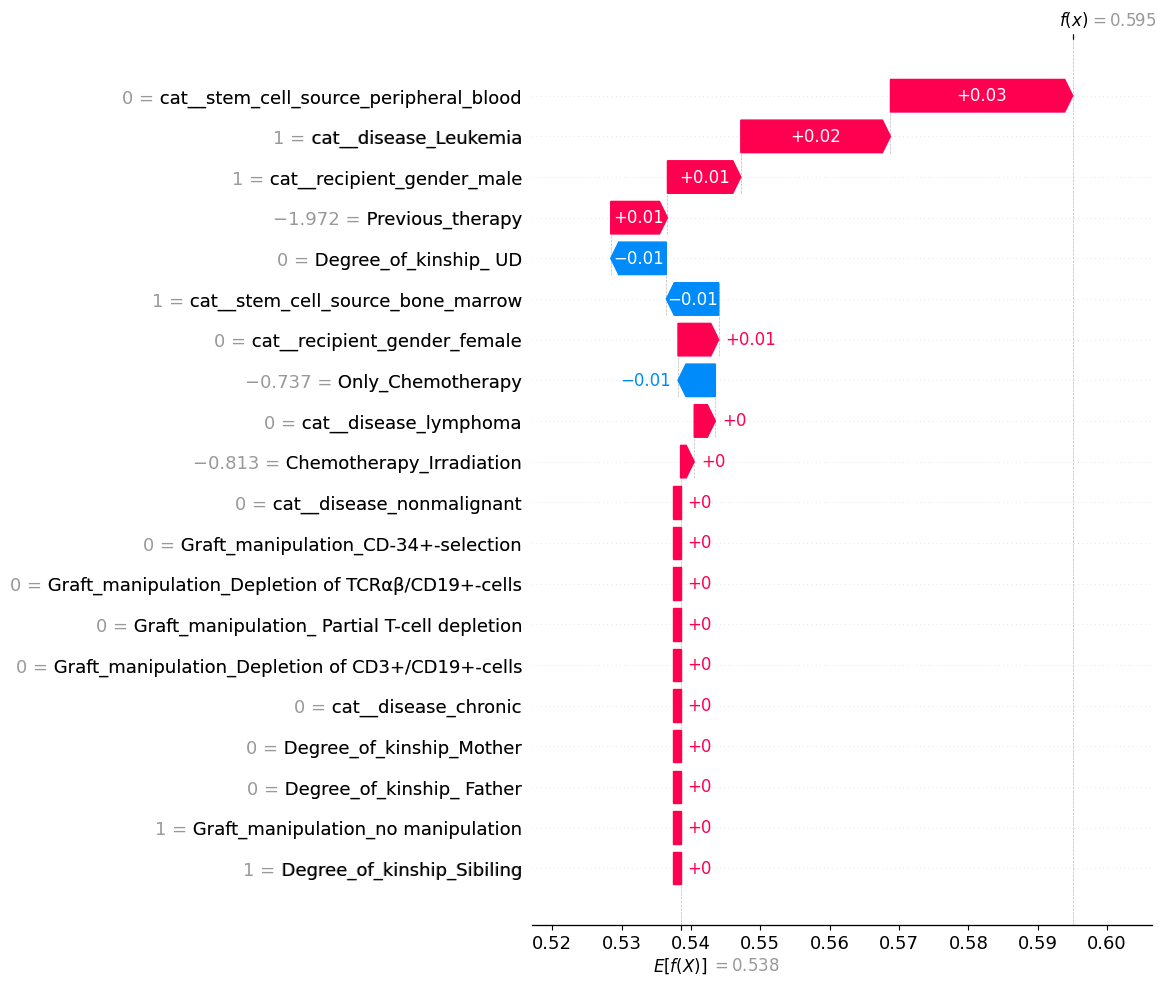

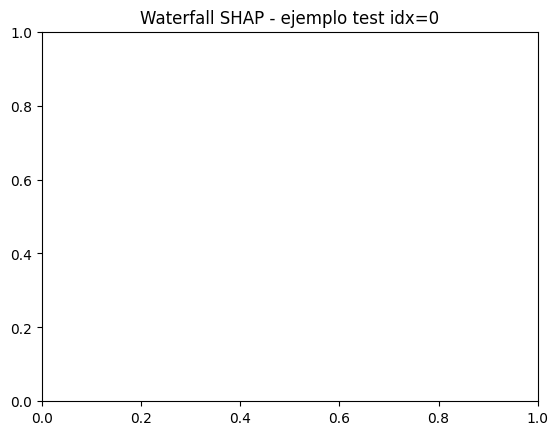

In [60]:
import shap
import matplotlib.pyplot as plt

idx = 0  # ejemplo de test a explicar

exp = shap.Explanation(
    values      = shap_values[idx],
    base_values = explainer.expected_value,
    data        = X_test_sample[idx],
    feature_names = feature_names,
)

shap.plots.waterfall(exp, max_display=20)
plt.title(f"Waterfall SHAP - ejemplo test idx={idx}")
plt.show()


#PDP/ALE

In [61]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin

class KerasTwoInputWrapper(BaseEstimator, ClassifierMixin):
    """
    Envuelve model_308 para que podamos usarlo con PDP/ALE.
    X: matriz 2D con todas las columnas concatenadas [X_existing | X_new]
    """
    def __init__(self, keras_model, n_exist, feature_names=None):
        self.model = keras_model
        self.n_exist = n_exist
        self.feature_names_in_ = np.array(feature_names) if feature_names is not None else None
        self.classes_ = np.array([0, 1])  # 0 = no GvHD, 1 = GvHD

    def fit(self, X, y=None):
        # Does not retrain: it only exists to comply with the sklearn interface
        return self

    def predict_proba(self, X):
        X = np.asarray(X)
        X_e = X[:, :self.n_exist]
        X_n = X[:, self.n_exist:]
        proba_pos = self.model.predict([X_e, X_n], verbose=0).ravel()
        proba_neg = 1.0 - proba_pos
        return np.vstack([proba_neg, proba_pos]).T

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= 0.5).astype(int)

wrapper = KerasTwoInputWrapper(model, n_exist, feature_names)

# DataFrame with all features
X_train_df = pd.DataFrame(X_train_all, columns=feature_names)


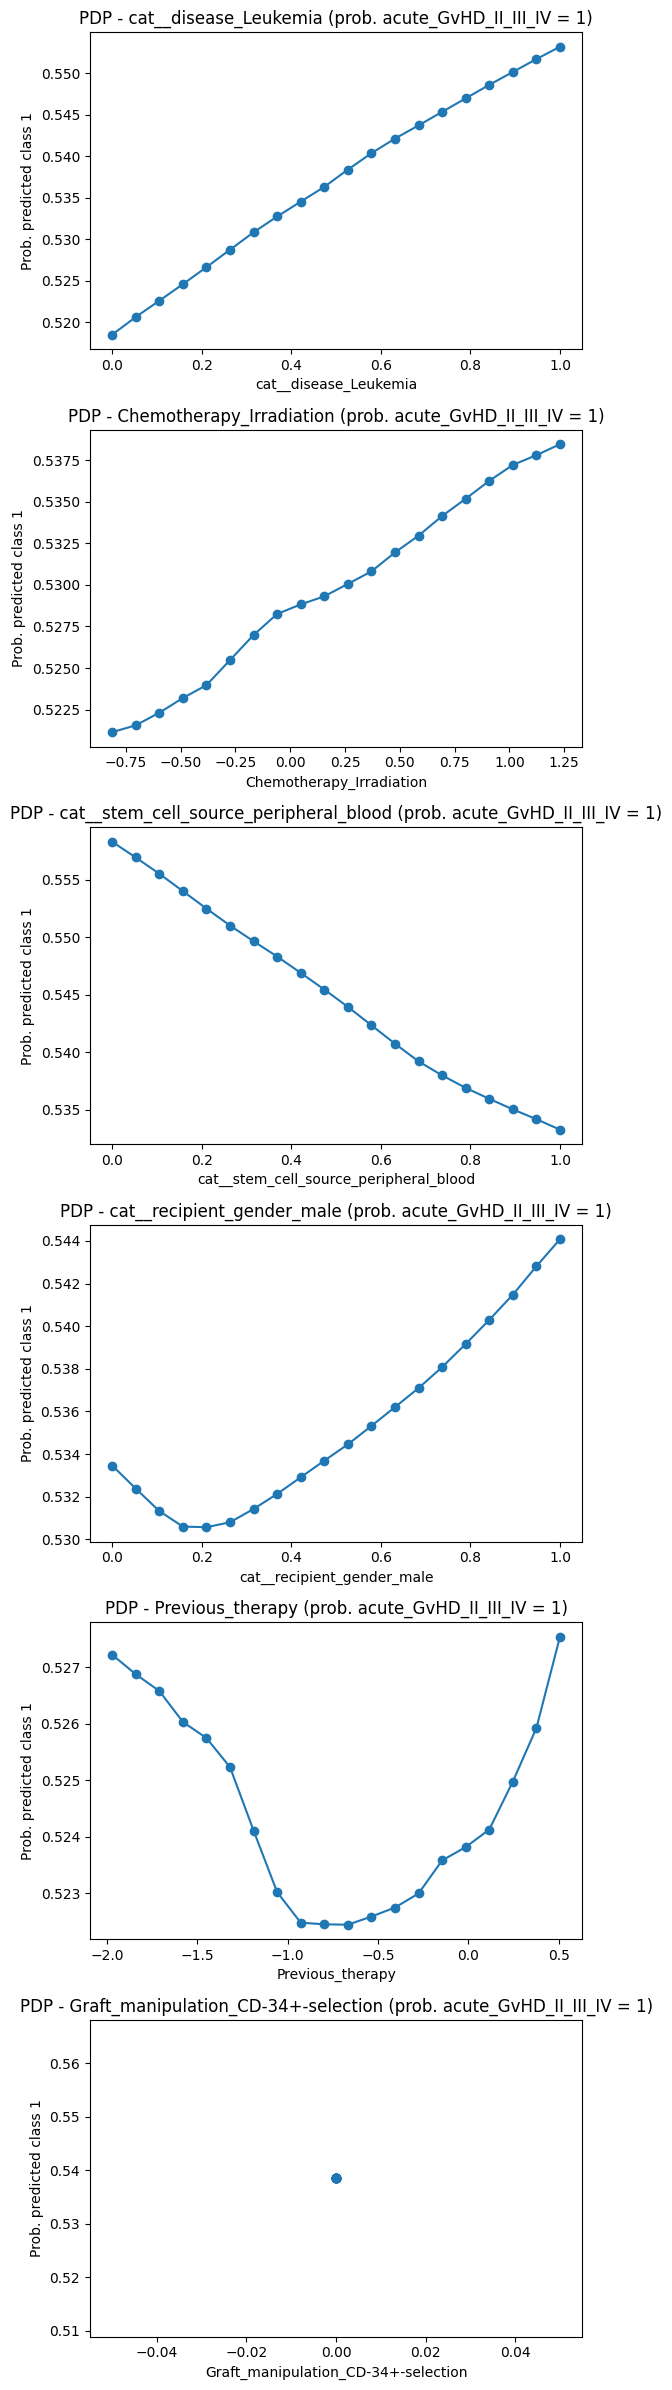

In [62]:
import numpy as np
import matplotlib.pyplot as plt

def compute_pdp_1d(model, X_df, feature, grid=None, grid_resolution=20, class_idx=1):
    """
    PDP 1D: para cada valor de 'feature' en 'grid', fijamos esa columna
    en todo X_df y promediamos la probabilidad de la clase 'class_idx'.
    """
    x = X_df[feature].values

    # Si no damos grid, lo construimos:
    if grid is None:
        if np.issubdtype(x.dtype, np.number):
            # rango 5–95 percentil para evitar outliers extremos
            vmin, vmax = np.percentile(x, 5), np.percentile(x, 95)
            grid = np.linspace(vmin, vmax, grid_resolution)
        else:
            # categorical: we use the unique values
            grid = np.sort(pd.unique(x))

    pdp_vals = []
    X_tmp = X_df.copy()

    for val in grid:
        X_tmp[feature] = val
        proba = model.predict_proba(X_tmp.values)[:, class_idx]
        pdp_vals.append(proba.mean())

    return np.array(grid), np.array(pdp_vals)

# --------- elegir features a analizar ---------
features_pdp = [
    "cat__disease_Leukemia",
    "Chemotherapy_Irradiation",
    "cat__stem_cell_source_peripheral_blood",
    "cat__recipient_gender_male",
    "Previous_therapy",
    "Graft_manipulation_CD-34+-selection",
]

fig, axes = plt.subplots(len(features_pdp), 1, figsize=(6, 4 * len(features_pdp)))

if len(features_pdp) == 1:
    axes = [axes]

for ax, feat in zip(axes, features_pdp):
    grid, pdp_vals = compute_pdp_1d(wrapper, X_train_df, feat)
    ax.plot(grid, pdp_vals, marker="o")
    ax.set_title(f"PDP - {feat} (prob. acute_GvHD_II_III_IV = 1)")
    ax.set_ylabel("Prob. predicted class 1")
    ax.set_xlabel(feat)

plt.tight_layout()
plt.tight_layout()
# ✅ Save in high quality for the paper (vector PDF)
out_pdf = "pdp_plots_highres.pdf"
fig.savefig(out_pdf, format="pdf", bbox_inches="tight")  # vectorial, ideal para paper

# (optional) also a 600 dpi PNG version
# fig.savefig("pdp_plots_highres.png", dpi=600, bbox_inches="tight")

plt.show()



INFO:PyALE._ALE_generic:Discrete feature detected.


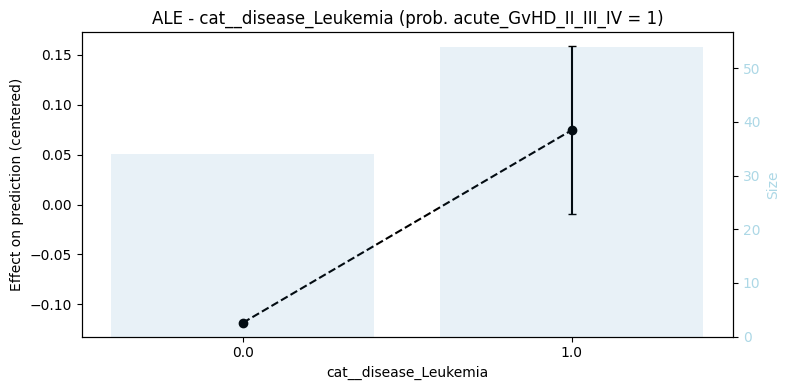

INFO:PyALE._ALE_generic:Discrete feature detected.


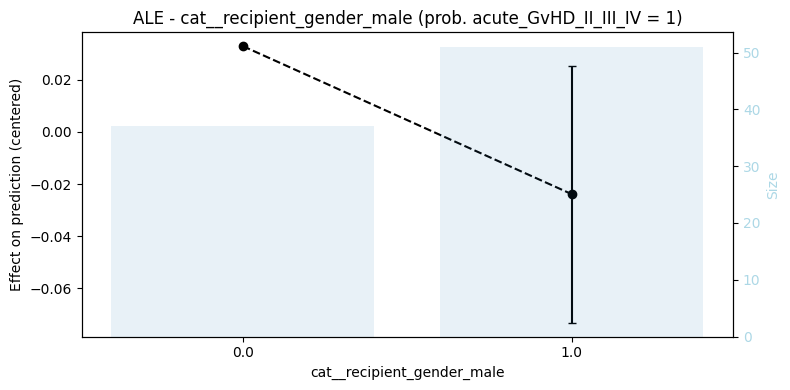

INFO:PyALE._ALE_generic:Discrete feature detected.


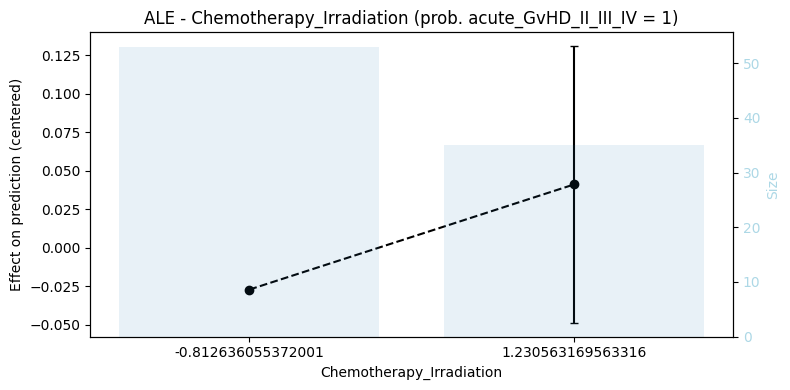

INFO:PyALE._ALE_generic:Discrete feature detected.


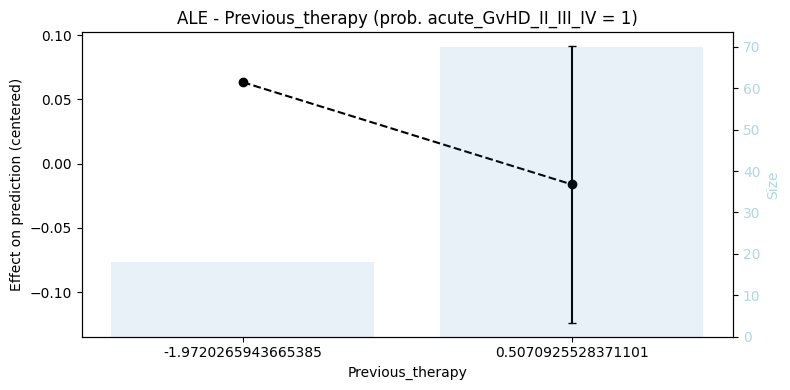

INFO:PyALE._ALE_generic:Discrete feature detected.


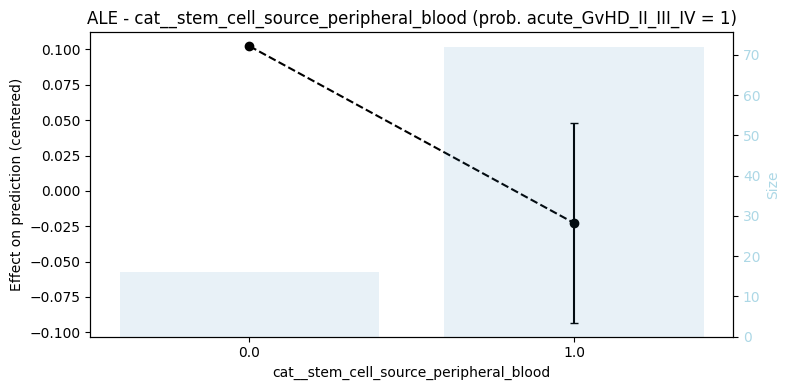

INFO:PyALE._ALE_generic:Discrete feature detected.


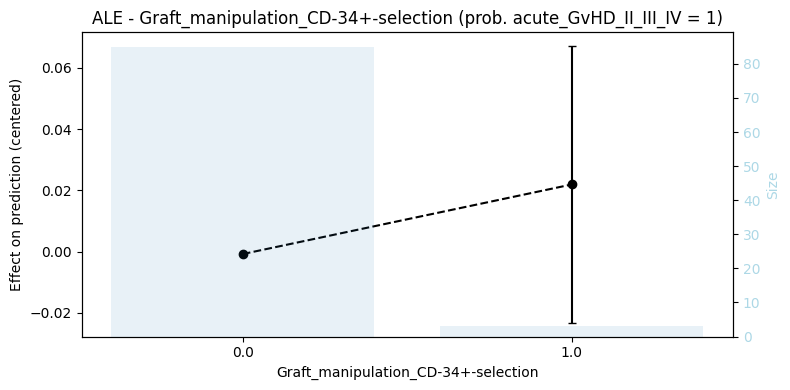

In [63]:
!pip install PyALE

from PyALE import ale
import matplotlib.pyplot as plt

# ALE for recipient age
ale(
    X=X_train_df,
    model=wrapper,
    feature=["cat__disease_Leukemia"],
    grid_size=20,
)
plt.title("ALE - cat__disease_Leukemia (prob. acute_GvHD_II_III_IV = 1)")
out_pdf1 = "ALE_cat__disease_Leukemia.pdf"
plt.savefig(out_pdf1, format="pdf", bbox_inches="tight")  # vectorial, ideal para paper
plt.show()


# ALE for recipient age
ale(
    X=X_train_df,
    model=wrapper,
    feature=["cat__recipient_gender_male"],
    grid_size=20,
)
plt.title("ALE - cat__recipient_gender_male (prob. acute_GvHD_II_III_IV = 1)")
out_pdf2 = "ALE_cat__recipient_gender_male.pdf"
plt.savefig(out_pdf2, format="pdf", bbox_inches="tight")
plt.show()

# ALE for HLA_match
ale(
    X=X_train_df,
    model=wrapper,
    feature=["Chemotherapy_Irradiation"],
    grid_size=10,
)
plt.title("ALE - Chemotherapy_Irradiation (prob. acute_GvHD_II_III_IV = 1)")
out_pdf3 = "ALE_Chemotherapy_Irradiation.pdf"
plt.savefig(out_pdf3, format="pdf", bbox_inches="tight")
plt.show()

# ALE for donor_CMV_absent (binary 0/1)
ale(
    X=X_train_df,
    model=wrapper,
    feature=["Previous_therapy"],
    grid_size=2,
)
plt.title("ALE - Previous_therapy (prob. acute_GvHD_II_III_IV = 1)")
out_pdf4 = "ALE_Previous_therapy.pdf"
plt.savefig(out_pdf4, format="pdf", bbox_inches="tight")
plt.show()

# ALE for donor_CMV_absent (binary 0/1)
ale(
    X=X_train_df,
    model=wrapper,
    feature=["cat__stem_cell_source_peripheral_blood"],
    grid_size=2,
)
plt.title("ALE - cat__stem_cell_source_peripheral_blood (prob. acute_GvHD_II_III_IV = 1)")
out_pdf5 = "ALE_cat__stem_cell_source_peripheral_blood.pdf"
plt.savefig(out_pdf5, format="pdf", bbox_inches="tight")
plt.show()

# ALE for donor_CMV_absent (binary 0/1)
ale(
    X=X_train_df,
    model=wrapper,
    feature=["Graft_manipulation_CD-34+-selection"],
    grid_size=2,
)
plt.title("ALE - Graft_manipulation_CD-34+-selection (prob. acute_GvHD_II_III_IV = 1)")
out_pdf6 = "ALE_Graft_manipulation_CD-34+-selection.pdf"
plt.savefig(out_pdf6, format="pdf", bbox_inches="tight")
plt.show()


#Dalex

In [64]:
class KerasTwoInputWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, keras_model, n_exist, feature_names=None):
        self.model = keras_model
        self.n_exist = n_exist
        self.feature_names_in_ = np.array(feature_names) if feature_names is not None else None
        self.classes_ = np.array([0, 1])

    def fit(self, X, y=None):
        return self

    def predict_proba(self, X):
        X = np.asarray(X)
        X_e = X[:, :self.n_exist]
        X_n = X[:, self.n_exist:]
        proba_pos = self.model.predict([X_e, X_n], verbose=0).ravel()
        proba_neg = 1.0 - proba_pos
        return np.vstack([proba_neg, proba_pos]).T

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= 0.5).astype(int)

wrapper = KerasTwoInputWrapper(model, n_exist, feature_names)


In [65]:
X_train_df = pd.DataFrame(X_train_all, columns=feature_names)
X_test_df  = pd.DataFrame(X_test_all,  columns=feature_names)


In [66]:
!pip install dalex

In [67]:
import dalex as dx
import numpy as np
# Make sure y_train is a 1D vector of 0/1
y_train_1d = np.array(y_train).ravel()

# In DALEX for binary classification:
# - model: objeto sklearn-like con predict / predict_proba
# - data: DataFrame con features
# - y: vector de 0/1
# - predict_function: function that returns the positive-class probability

def predict_proba_pos(model, data):
    """
    DALEX la va a llamar como predict_proba_pos(model, data)

    - model: nuestro wrapper (KerasTwoInputWrapper)
    - data: DataFrame o array con las features
    """
    proba = model.predict_proba(data)
    return proba[:, 1]   # prob. de la clase 1 = acute_GvHD_II_III_IV




exp_dalex = dx.Explainer(
    model=wrapper,
    data=X_train_df,
    y=y_train_1d,
    predict_function=predict_proba_pos,
    label="Dalex Global Feature Importance on UCHW dataset - model BMTCH-UCHW",
)


Preparation of a new explainer is initiated

  -> data              : 88 rows 20 cols
  -> target variable   : 88 values
  -> model_class       : __main__.KerasTwoInputWrapper (default)
  -> label             : Dalex Global Feature Importance on UCHW dataset - model BMTCH-UCHW
  -> predict function  : <function predict_proba_pos at 0x7a2165c544a0> will be used
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.432, mean = 0.538, max = 0.598
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.598, mean = 0.0524, max = 0.568
  -> model_info        : package __main__

A new explainer has been created!


In [68]:
vi = exp_dalex.model_parts(type="variable_importance")
vi.result.head()
fig = vi.plot(max_vars=20,show=False)
pio.write_image(
    fig,
    "dalex_variable_importance.pdf",
    format="pdf",
    width=1400,   # controls size/layout
    height=900
)
vi.plot(max_vars=20)

In [69]:
pdp_graft = exp_dalex.model_profile(
    variables=["Graft_manipulation_CD-34+-selection"],
    type="partial"
)

pdp_graft.plot()

Calculating ceteris paribus: 100%|██████████| 1/1 [00:00<00:00,  1.11it/s]
